In [1]:
import numpy as np
import pandas as pd
from bh_molecule.calibration import (
    analyze_wavelength_linearity,
    plot_linearity_summary,
    plot_fiber_line_fits,
)

In [2]:
d = pd.read_csv("133mVis_wavcal.csv", index_col=0, header=None)
m = d.values
print(f"Matrix shape: {m.shape}")

Matrix shape: (44, 1024)


In [3]:
result = analyze_wavelength_linearity(m)

(<Figure size 2080x640 with 8 Axes>,
 array([[<Axes: title={'center': 'fiber 4 | RMSE=0.00101'}, xlabel='pixel'>,
         <Axes: title={'center': 'fiber 3 | RMSE=0.00101'}, xlabel='pixel'>,
         <Axes: title={'center': 'fiber 5 | RMSE=0.00101'}, xlabel='pixel'>,
         <Axes: title={'center': 'fiber 8 | RMSE=0.00101'}, xlabel='pixel'>],
        [<Axes: title={'center': 'fiber 2 | RMSE=0.00101'}, xlabel='pixel'>,
         <Axes: title={'center': 'fiber 7 | RMSE=0.00101'}, xlabel='pixel'>,
         <Axes: title={'center': 'fiber 6 | RMSE=0.00101'}, xlabel='pixel'>,
         <Axes: title={'center': 'fiber 1 | RMSE=0.00101'}, xlabel='pixel'>]],
       dtype=object))

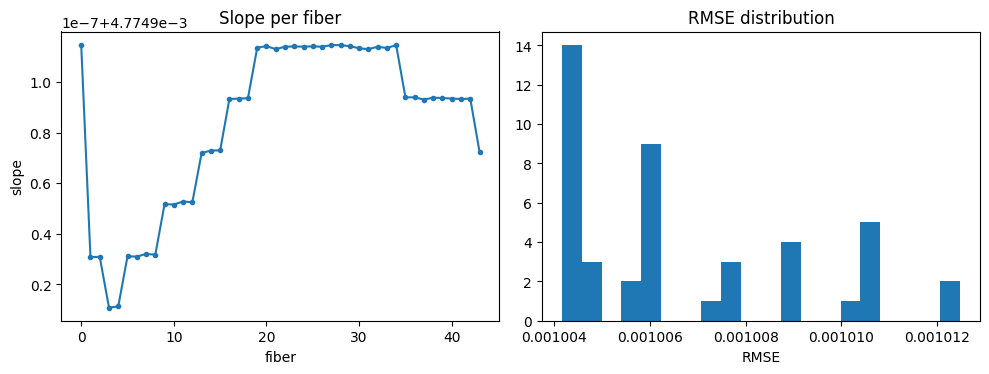

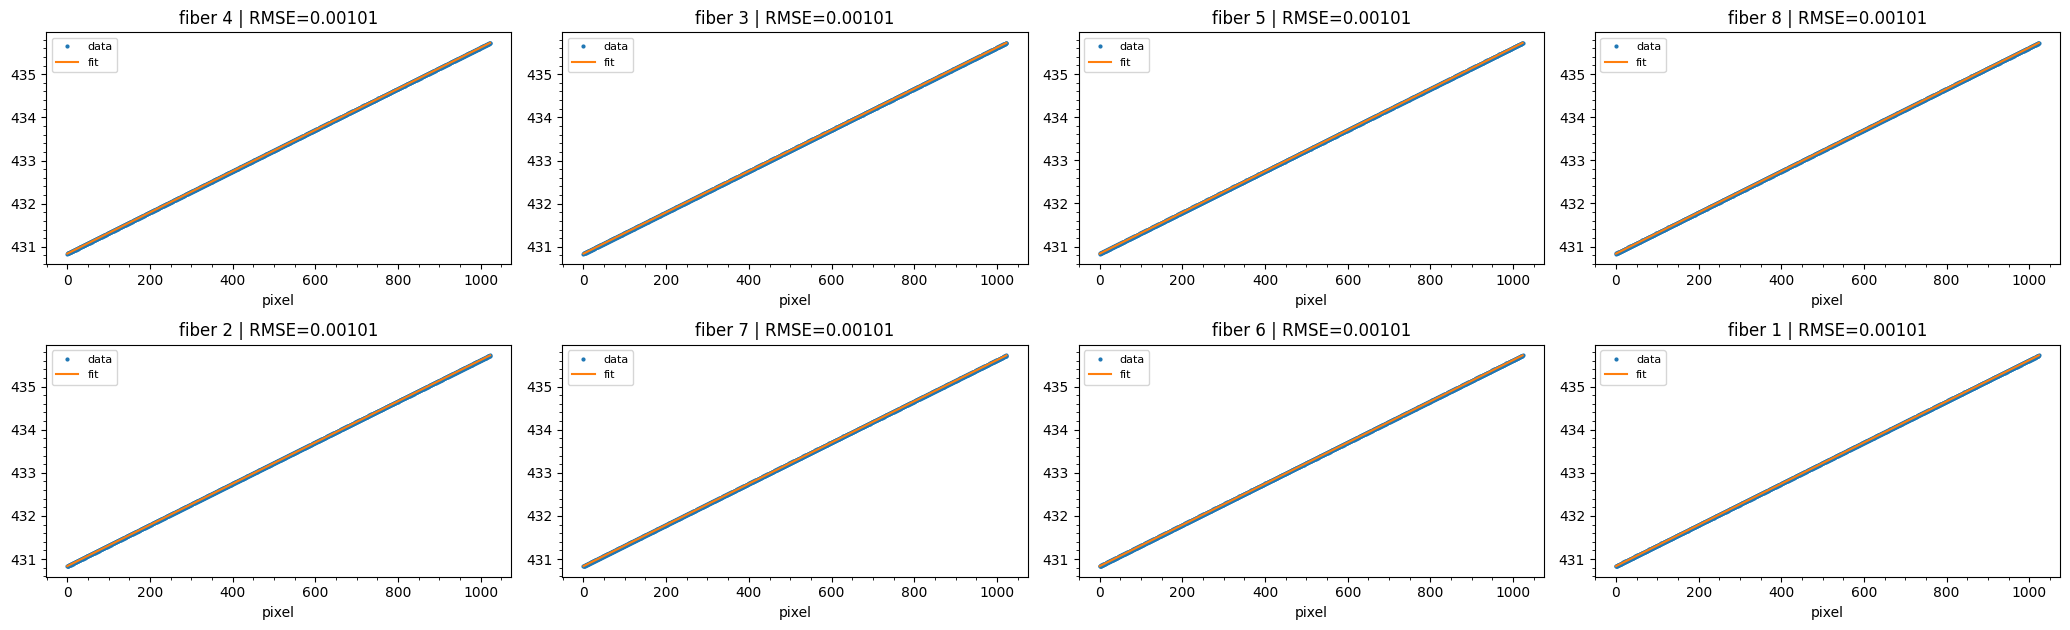

In [4]:
df = pd.DataFrame(
    {
        "row": np.arange(len(result["slopes"])),
        "slope": result["slopes"],
        "intercept": result["intercepts"],
        "r2": result["r2"],
        "rmse": result["rmse"],
    }
)
df.to_csv("calibration_linearity_summary.csv", index=False)
plot_linearity_summary(result["slopes"], result["r2"], result["rmse"])
plot_fiber_line_fits(m, result["slopes"], result["intercepts"])

In [5]:
df


,row,slope,intercept,r2,rmse
0,0,0.004775,430.817928,0.999999,0.001004
1,1,0.004775,430.837074,0.999999,0.001010
2,2,0.004775,430.837033,0.999999,0.001011
3,3,0.004775,430.841851,0.999999,0.001012
4,4,0.004775,430.841862,0.999999,0.001012
5,5,0.004775,430.837055,0.999999,0.001011
6,6,0.004775,430.837062,0.999999,0.001010
7,7,0.004775,430.837088,0.999999,0.001011
8,8,0.004775,430.837095,0.999999,0.001011
9,9,0.004775,430.832269,0.999999,0.001009
